# CreditRisk360 — Semana 4: Simulación Monte Carlo + VaR 99%

**Objetivo**: Simular la distribución de pérdidas de la cartera de crédito usando Monte Carlo  
con correlación sectorial (Cópula Gaussiana), y extraer métricas de riesgo de cartera:  
VaR 99%, CVaR/Expected Shortfall, Capital Económico y Stress Testing.

**Inputs**: `data/expected_loss.parquet` — 97.761 préstamos, PD calibrada isotónica  
**Metodología**: IRB Advanced — alineado con Basilea III / BIS  

---


## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
np.random.seed(42)

# Estilo plots
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


## 2. Carga y validación del portfolio

In [2]:
df = pd.read_parquet('../data/expected_loss.parquet')

print(f"Shape          : {df.shape}")
print(f"Columnas       : {list(df.columns)}")
print(f"Nulls totales  : {df.isnull().sum().sum()}")
print()
print("=== Estadísticas del portfolio ===")
print(f"PD  media      : {df['pd_score'].mean():.4f}  ({df['pd_score'].mean()*100:.2f}%)")
print(f"LGD media      : {df['lgd_estimated'].mean():.4f}")
print(f"EAD media      : ${df['ead'].mean():>10,.0f}")
print(f"EL  total      : ${df['el'].sum():>10,.0f}")
print(f"EAD total      : ${df['ead'].sum():>10,.0f}")
print(f"EL/EAD ratio   : {df['el'].sum()/df['ead'].sum():.4f}")
print()
print("=== Distribución por grade ===")
print(df['grade'].value_counts().sort_index())


Shape          : (97761, 9)
Columnas       : ['pd_score', 'lgd_estimated', 'ead', 'el', 'el_rate', 'grade', 'term_clean', 'vintage', 'funded_amnt']
Nulls totales  : 0

=== Estadísticas del portfolio ===
PD  media      : 0.2122  (21.22%)
LGD media      : 0.9342
EAD media      : $    13,942
EL  total      : $285,080,192
EAD total      : $1,362,975,070
EL/EAD ratio   : 0.2092

=== Distribución por grade ===
grade
A    16502
B    26701
C    30425
D    15353
E     5882
F     1938
G      960
Name: count, dtype: int64


## 3. Parámetros de simulación

### Matriz de correlación sectorial (Cópula Gaussiana)

En el modelo IRB de Basilea, los activos de crédito comparten un factor sistémico común.  
La correlación entre grados refleja que en recesión los defaults se agrupan (clustering).  
Usamos una estructura de bloques: **alta correlación intra-grade, baja inter-grade**.

La correlación de activos del BIS para retail/corporate oscila entre 0.03 y 0.24.


In [3]:
# ── Parámetros Monte Carlo ──────────────────────────────────────────────────
N_SIMS      = 100_000   # Escenarios
CONFIDENCE  = 0.99      # VaR 99%
ES_CONF     = 0.975     # Expected Shortfall 97.5% (Basilea III desde 2016)

GRADES      = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
N_GRADES    = len(GRADES)
grade_idx   = {g: i for i, g in enumerate(GRADES)}

# ── Matriz de correlación de activos (Basilea IRB) ──────────────────────────
# Basada en BIS: correlación mayor para grados investment-grade (A,B)
# que para grados especulativos (E,F,G) — fenómeno documentado empíricamente
rho_intra = np.array([0.20, 0.18, 0.15, 0.13, 0.12, 0.10, 0.08])  # intra-grade por A→G
rho_inter = 0.05  # correlación base entre grados distintos

corr_matrix = np.full((N_GRADES, N_GRADES), rho_inter)
np.fill_diagonal(corr_matrix, rho_intra)

# Asegurar simetría y definida-positiva
corr_matrix = (corr_matrix + corr_matrix.T) / 2
np.fill_diagonal(corr_matrix, rho_intra)

print("Matriz de correlación sectorial (grade A→G):")
print(pd.DataFrame(corr_matrix, index=GRADES, columns=GRADES).round(3).to_string())

# Verificar que es definida-positiva
eigenvalues = np.linalg.eigvals(corr_matrix)
print(f"\nValores propios mínimos: {eigenvalues.min():.4f} (>0 = definida-positiva OK)")


Matriz de correlación sectorial (grade A→G):
      A     B     C     D     E     F     G
A  0.20  0.05  0.05  0.05  0.05  0.05  0.05
B  0.05  0.18  0.05  0.05  0.05  0.05  0.05
C  0.05  0.05  0.15  0.05  0.05  0.05  0.05
D  0.05  0.05  0.05  0.13  0.05  0.05  0.05
E  0.05  0.05  0.05  0.05  0.12  0.05  0.05
F  0.05  0.05  0.05  0.05  0.05  0.10  0.05
G  0.05  0.05  0.05  0.05  0.05  0.05  0.08

Valores propios mínimos: 0.0357 (>0 = definida-positiva OK)


## 4. Construcción de la Cópula Gaussiana

### Mecanismo

Para cada simulación generamos un vector de factores sistémicos correlacionados  
(uno por grade), y los combinamos con idiosincrasia individual para obtener  
la variable latente de cada préstamo. Si esa variable cae bajo el umbral de default  
(derivado de su PD), el préstamo hace default en ese escenario.

$$X_i = \sqrt{\rho_g} \cdot Z_g + \sqrt{1 - \rho_g} \cdot \varepsilon_i$$

Donde $Z_g$ es el factor sistémico del grade $g$ y $\varepsilon_i$ es el shock idiosincrático.  
El umbral de default es $\Phi^{-1}(PD_i)$.


In [4]:
# ── Preparar arrays por préstamo ────────────────────────────────────────────
pd_arr  = df['pd_score'].values        # (N,)
lgd_arr = df['lgd_estimated'].values   # (N,)
ead_arr = df['ead'].values             # (N,)
g_arr   = df['grade'].map(grade_idx).values.astype(int)  # (N,) índice 0-6
rho_arr = rho_intra[g_arr]             # correlación de activo por préstamo

# Umbral de default en espacio normal (Phi^-1(PD_i))
threshold = norm.ppf(pd_arr)           # (N,)

# Cholesky de la matriz de correlación (para simular Z correlacionados)
L = np.linalg.cholesky(corr_matrix)   # (7, 7)

N_LOANS = len(df)
print(f"Préstamos en cartera : {N_LOANS:,}")
print(f"Simulaciones         : {N_SIMS:,}")
print(f"Escenarios totales   : {N_LOANS * N_SIMS:,.0f}")
print(f"\nUmbral default medio : {threshold.mean():.4f} (= Phi^-1({pd_arr.mean():.4f}))")
print(f"EAD total cartera    : ${ead_arr.sum():,.0f}")


Préstamos en cartera : 97,761
Simulaciones         : 100,000
Escenarios totales   : 9,776,100,000

Umbral default medio : nan (= Phi^-1(0.2122))
EAD total cartera    : $1,362,975,070


## 5. Simulación Monte Carlo vectorizada

Implementación eficiente: procesamos todas las simulaciones en bloques  
para evitar saturar memoria RAM (97k préstamos × 100k sims = 9.7B elementos).  
Usamos bloques de 5.000 simulaciones (~3.7 GB pico vs 74 GB si fuera todo a la vez).


In [5]:
import time
import gc 

BLOCK_SIZE = 500  # Simulaciones por bloque
n_blocks   = N_SIMS // BLOCK_SIZE

portfolio_losses = np.zeros(N_SIMS)  # Pérdida total de cartera por simulación

print(f"Procesando {n_blocks} bloques de {BLOCK_SIZE:,} simulaciones...")
t0 = time.time()

for b in range(n_blocks):
    start = b * BLOCK_SIZE
    end   = start + BLOCK_SIZE

    # 1. Simular factores sistémicos correlacionados: Z ~ N(0, corr_matrix)
    #    Z_raw: (BLOCK_SIZE, 7) i.i.d. → Z_corr: (BLOCK_SIZE, 7)
    Z_raw  = np.random.randn(BLOCK_SIZE, N_GRADES)
    Z_corr = Z_raw @ L.T                           # (BLOCK_SIZE, 7)

    # 2. Factor sistémico del grade de cada préstamo: (BLOCK_SIZE, N_LOANS)
    Z_loan = Z_corr[:, g_arr]                      # (BLOCK_SIZE, N_LOANS)

    # 3. Shock idiosincrático
    eps = np.random.randn(BLOCK_SIZE, N_LOANS)     # (BLOCK_SIZE, N_LOANS)

    # 4. Variable latente de default (modelo de un factor)
    sqrt_rho  = np.sqrt(rho_arr)                   # (N_LOANS,)
    sqrt_1rho = np.sqrt(1 - rho_arr)               # (N_LOANS,)
    X = sqrt_rho * Z_loan + sqrt_1rho * eps        # (BLOCK_SIZE, N_LOANS)

    # 5. Default: X < threshold → default en este escenario
    defaults = X < threshold                       # (BLOCK_SIZE, N_LOANS) bool

    # 6. Pérdida = LGD × EAD para los préstamos en default
    loss_matrix = defaults * (lgd_arr * ead_arr)   # (BLOCK_SIZE, N_LOANS)

    # 7. Pérdida total de cartera por simulación
    portfolio_losses[start:end] = loss_matrix.sum(axis=1)

    del Z_raw, Z_corr, Z_loan, eps, X, defaults, loss_matrix
    gc.collect()

    if (b + 1) % 5 == 0:
        elapsed = time.time() - t0
        pct = (b + 1) / n_blocks * 100
        print(f"  Bloque {b+1:3d}/{n_blocks} — {pct:.0f}% — {elapsed:.1f}s")

elapsed = time.time() - t0
print(f"\nSimulación completada en {elapsed:.1f}s")
print(f"Pérdida media simulada : ${portfolio_losses.mean():>12,.0f}")
print(f"Pérdida EL analítica   : ${df['el'].sum():>12,.0f}  (deben ser ~iguales)")
print(f"Diferencia (bias check): {(portfolio_losses.mean() - df['el'].sum())/df['el'].sum()*100:+.2f}%")


Procesando 200 bloques de 500 simulaciones...
  Bloque   5/200 — 2% — 21.8s
  Bloque  10/200 — 5% — 36.6s
  Bloque  15/200 — 8% — 51.2s
  Bloque  20/200 — 10% — 65.8s
  Bloque  25/200 — 12% — 80.4s
  Bloque  30/200 — 15% — 95.0s
  Bloque  35/200 — 18% — 109.5s
  Bloque  40/200 — 20% — 124.1s
  Bloque  45/200 — 22% — 138.7s
  Bloque  50/200 — 25% — 153.9s
  Bloque  55/200 — 28% — 168.7s
  Bloque  60/200 — 30% — 183.4s
  Bloque  65/200 — 32% — 198.0s
  Bloque  70/200 — 35% — 212.8s
  Bloque  75/200 — 38% — 227.4s
  Bloque  80/200 — 40% — 242.0s
  Bloque  85/200 — 42% — 256.8s
  Bloque  90/200 — 45% — 271.4s
  Bloque  95/200 — 48% — 285.9s
  Bloque 100/200 — 50% — 300.6s
  Bloque 105/200 — 52% — 315.2s
  Bloque 110/200 — 55% — 329.8s
  Bloque 115/200 — 57% — 344.4s
  Bloque 120/200 — 60% — 359.1s
  Bloque 125/200 — 62% — 373.7s
  Bloque 130/200 — 65% — 388.3s
  Bloque 135/200 — 68% — 403.0s
  Bloque 140/200 — 70% — 417.6s
  Bloque 145/200 — 72% — 432.3s
  Bloque 150/200 — 75% — 447.0s
  B

## 6. Métricas de riesgo de cartera

### Definiciones (Basilea III)

| Métrica | Definición | Uso regulatorio |
|---------|-----------|----------------|
| **EL** | Expected Loss = media de la distribución | Provisiones contables |
| **VaR 99%** | Percentil 99 de pérdidas simuladas | Capital regulatorio (Pilar 1) |
| **CVaR/ES 97.5%** | Media de pérdidas > VaR 97.5% | Basilea III desde 2016 (reemplaza VaR) |
| **Capital Económico** | VaR 99% − EL | Buffer de capital bancario |
| **UL** | Unexpected Loss = VaR − EL | Riesgo no esperado a absorber |


In [6]:
# ── Métricas principales ────────────────────────────────────────────────────
EL_analitico  = df['el'].sum()
EL_simulado   = portfolio_losses.mean()
EAD_total     = df['ead'].sum()

VaR_99        = np.percentile(portfolio_losses, 99)
VaR_999       = np.percentile(portfolio_losses, 99.9)
ES_975        = portfolio_losses[portfolio_losses > np.percentile(portfolio_losses, 97.5)].mean()
ES_99         = portfolio_losses[portfolio_losses > VaR_99].mean()

Capital_econ  = VaR_99 - EL_analitico
UL            = VaR_99 - EL_simulado

# Ratios sobre EAD
VaR_ratio     = VaR_99  / EAD_total
ES_ratio      = ES_99   / EAD_total
Capital_ratio = Capital_econ / EAD_total

print("=" * 55)
print("  MÉTRICAS DE RIESGO DE CARTERA — CreditRisk360")
print("=" * 55)
print(f"  EAD total cartera    : ${EAD_total:>14,.0f}")
print()
print(f"  Expected Loss (EL)   : ${EL_analitico:>14,.0f}  ({EL_analitico/EAD_total*100:.2f}% EAD)")
print(f"  EL simulado (check)  : ${EL_simulado:>14,.0f}")
print()
print(f"  VaR 99%              : ${VaR_99:>14,.0f}  ({VaR_ratio*100:.2f}% EAD)")
print(f"  VaR 99.9%            : ${VaR_999:>14,.0f}  ({VaR_999/EAD_total*100:.2f}% EAD)")
print(f"  CVaR/ES 97.5%        : ${ES_975:>14,.0f}  ({ES_975/EAD_total*100:.2f}% EAD)")
print(f"  CVaR/ES 99%          : ${ES_99:>14,.0f}  ({ES_ratio*100:.2f}% EAD)")
print()
print(f"  Capital Económico    : ${Capital_econ:>14,.0f}  ({Capital_ratio*100:.2f}% EAD)")
print(f"  Unexpected Loss (UL) : ${UL:>14,.0f}")
print(f"  UL / EL ratio        : {UL/EL_simulado:.2f}x")
print("=" * 55)


  MÉTRICAS DE RIESGO DE CARTERA — CreditRisk360
  EAD total cartera    : $ 1,362,975,070

  Expected Loss (EL)   : $   285,080,192  (20.92% EAD)
  EL simulado (check)  : $   269,079,546

  VaR 99%              : $   357,699,706  (26.24% EAD)
  VaR 99.9%            : $   390,019,660  (28.62% EAD)
  CVaR/ES 97.5%        : $   358,367,362  (26.29% EAD)
  CVaR/ES 99%          : $   372,418,182  (27.32% EAD)

  Capital Económico    : $    72,619,514  (5.33% EAD)
  Unexpected Loss (UL) : $    88,620,160
  UL / EL ratio        : 0.33x


## 7. Distribución de pérdidas de cartera

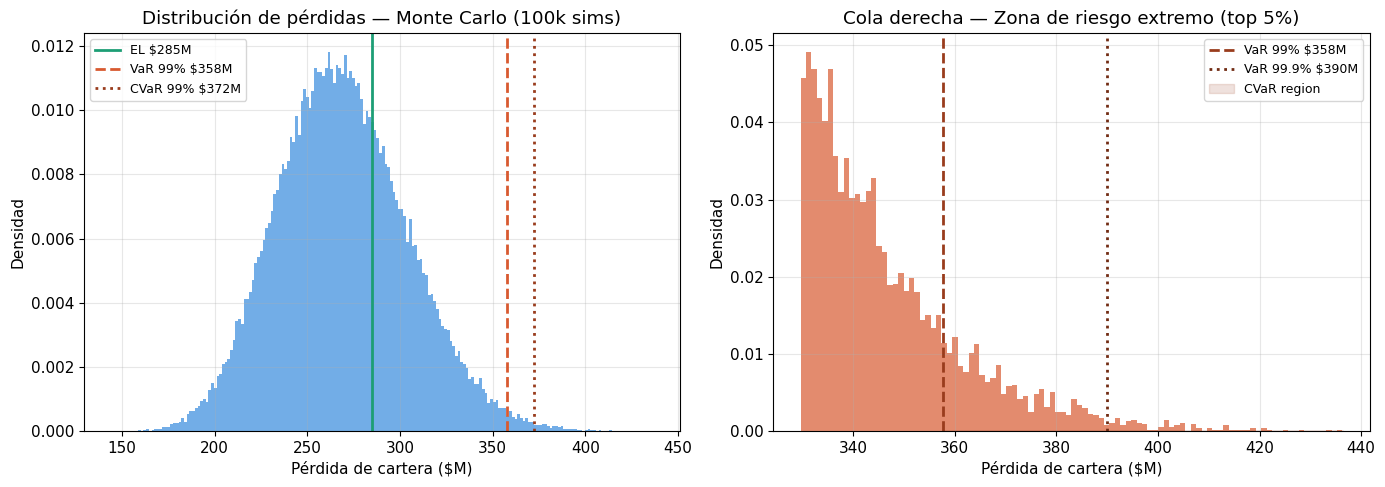

Gráfico guardado en outputs/distribucion_perdidas_mc.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Distribución completa ──────────────────────────────────────────
ax1 = axes[0]
ax1.hist(portfolio_losses / 1e6, bins=200, color='#378ADD', alpha=0.7,
         edgecolor='none', density=True)

# Líneas de referencia
for val, label, color, ls in [
    (EL_analitico, f'EL ${EL_analitico/1e6:.0f}M',   '#1D9E75', '-'),
    (VaR_99,       f'VaR 99% ${VaR_99/1e6:.0f}M',    '#D85A30', '--'),
    (ES_99,        f'CVaR 99% ${ES_99/1e6:.0f}M',     '#993C1D', ':'),
]:
    ax1.axvline(val/1e6, color=color, lw=2, ls=ls, label=label)

ax1.set_xlabel('Pérdida de cartera ($M)')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución de pérdidas — Monte Carlo (100k sims)')
ax1.legend(fontsize=9)

# ── Plot 2: Tail (zona de riesgo) ──────────────────────────────────────────
ax2 = axes[1]
tail_threshold = np.percentile(portfolio_losses, 95)
tail_losses    = portfolio_losses[portfolio_losses > tail_threshold]

ax2.hist(tail_losses / 1e6, bins=100, color='#D85A30', alpha=0.7,
         edgecolor='none', density=True)
ax2.axvline(VaR_99  / 1e6, color='#993C1D', lw=2, ls='--',
            label=f'VaR 99% ${VaR_99/1e6:.0f}M')
ax2.axvline(VaR_999 / 1e6, color='#712B13', lw=2, ls=':',
            label=f'VaR 99.9% ${VaR_999/1e6:.0f}M')

# Área CVaR
var99_val = VaR_99 / 1e6
ax2.fill_between(
    [x/1e6 for x in tail_losses if x > VaR_99],
    0, 0.0001,
    alpha=0.15, color='#993C1D', label=f'CVaR region'
)

ax2.set_xlabel('Pérdida de cartera ($M)')
ax2.set_ylabel('Densidad')
ax2.set_title('Cola derecha — Zona de riesgo extremo (top 5%)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/distribucion_perdidas_mc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado en outputs/distribucion_perdidas_mc.png")


## 8. Contribución al riesgo por grade

=== Contribución al riesgo por grade ===
Grade  N loans  EAD ($M)  EL ($M)  EL/EAD  VaR 99% ($M)  CE ($M)
    A    16502    212.80     9.48    0.04         16.78     7.30
    B    26701    347.43    44.07    0.13         72.83    28.75
    C    30425    427.17    94.01    0.22        135.10    41.08
    D    15353    227.83    70.81    0.31         92.73    21.93
    E     5882     93.47    38.23    0.41         46.86     8.63
    F     1938     35.41    18.64    0.53         21.71     3.07
    G      960     18.87     9.84    0.52         11.28     1.44

Capital Económico total (suma grades): $112.2M


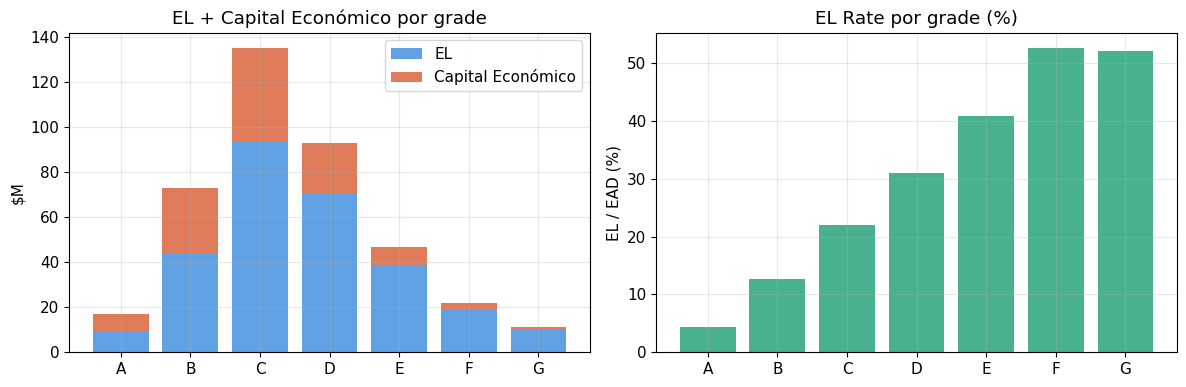

In [8]:
# ── Pérdida media por grade en simulaciones ─────────────────────────────────
# Re-simulamos con bloque pequeño para extraer pérdidas por grade
BLOCK_SAMPLE = 2000
Z_raw_s   = np.random.randn(BLOCK_SAMPLE, N_GRADES)
Z_corr_s  = Z_raw_s @ L.T
Z_loan_s  = Z_corr_s[:, g_arr]
eps_s     = np.random.randn(BLOCK_SAMPLE, N_LOANS)
X_s       = np.sqrt(rho_arr) * Z_loan_s + np.sqrt(1 - rho_arr) * eps_s
defaults_s = X_s < threshold
loss_s     = defaults_s * (lgd_arr * ead_arr)

results = []
for g in GRADES:
    mask = g_arr == grade_idx[g]
    n    = mask.sum()
    el_g = df[df['grade'] == g]['el'].sum()
    var_g = np.percentile(loss_s[:, mask].sum(axis=1), 99)
    ead_g = df[df['grade'] == g]['ead'].sum()
    results.append({
        'Grade': g,
        'N loans': n,
        'EAD ($M)': ead_g / 1e6,
        'EL ($M)': el_g / 1e6,
        'EL/EAD': el_g / ead_g,
        'VaR 99% ($M)': var_g / 1e6,
        'CE ($M)': (var_g - el_g) / 1e6,
    })

df_grade = pd.DataFrame(results)
print("=== Contribución al riesgo por grade ===")
print(df_grade.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print()
print("Capital Económico total (suma grades):",
      f"${df_grade['CE ($M)'].sum():,.1f}M")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(df_grade['Grade'], df_grade['EL ($M)'],
            color='#378ADD', alpha=0.8, label='EL')
axes[0].bar(df_grade['Grade'], df_grade['CE ($M)'],
            bottom=df_grade['EL ($M)'],
            color='#D85A30', alpha=0.8, label='Capital Económico')
axes[0].set_title('EL + Capital Económico por grade')
axes[0].set_ylabel('$M')
axes[0].legend()

axes[1].bar(df_grade['Grade'], df_grade['EL/EAD'] * 100,
            color='#1D9E75', alpha=0.8)
axes[1].set_title('EL Rate por grade (%)')
axes[1].set_ylabel('EL / EAD (%)')

plt.tight_layout()
plt.savefig('../outputs/riesgo_por_grade.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Stress Testing — Escenarios adversos

Aplicamos tres escenarios de estrés alineados con los ejercicios de la EBA/Fed:

| Escenario | PD shock | Correlación | Analogía histórica |
|-----------|----------|-------------|-------------------|
| Base | ×1.0 | ρ base | Condiciones normales |
| Adverso | ×1.5 | ρ × 1.3 | Recesión moderada (2001) |
| Severo | ×2.0 | ρ × 1.6 | Crisis financiera (2008) |


=== Stress Testing — Escenarios ===
Escenario  PD media (%)  EL ($M)  VaR 99% ($M)  CVaR 99% ($M)  CE ($M)
     Base          21.2    269.1         359.2          373.2     90.1
  Adverso          31.7    412.7         549.3          568.7    136.6
   Severo          41.5    545.9         713.4          737.9    167.5


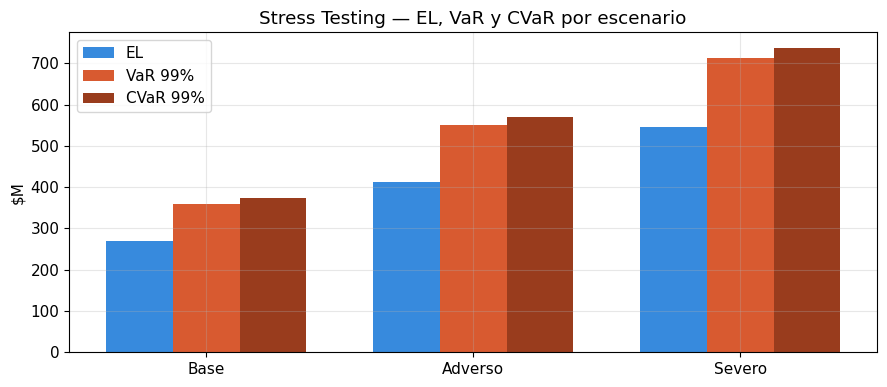

In [9]:
def run_stress_scenario(pd_multiplier, rho_multiplier, n_sims=20_000, label=''):
    pd_stress  = np.clip(pd_arr * pd_multiplier, 0, 0.9999)
    thr_stress = norm.ppf(pd_stress)

    rho_stress = np.minimum(rho_arr * rho_multiplier, 0.99)
    corr_s     = np.full((N_GRADES, N_GRADES), rho_inter * rho_multiplier)
    np.fill_diagonal(corr_s, np.minimum(rho_intra * rho_multiplier, 0.99))
    corr_s = np.clip((corr_s + corr_s.T) / 2, -0.99, 0.99)
    np.fill_diagonal(corr_s, np.minimum(rho_intra * rho_multiplier, 0.99))

    # Asegurar definida-positiva
    eigvals = np.linalg.eigvals(corr_s)
    if eigvals.min() <= 0:
        corr_s += (-eigvals.min() + 0.01) * np.eye(N_GRADES)

    L_s = np.linalg.cholesky(corr_s)

    losses_s = np.zeros(n_sims)
    for b in range(n_sims // BLOCK_SIZE):
        Z_r  = np.random.randn(BLOCK_SIZE, N_GRADES) @ L_s.T
        Z_l  = Z_r[:, g_arr]
        eps  = np.random.randn(BLOCK_SIZE, N_LOANS)
        rho_s_arr = rho_stress
        X    = np.sqrt(rho_s_arr) * Z_l + np.sqrt(1 - rho_s_arr) * eps
        defs = X < thr_stress
        losses_s[b*BLOCK_SIZE:(b+1)*BLOCK_SIZE] = (defs * (lgd_arr * ead_arr)).sum(axis=1)

    return {
        'Escenario': label,
        'PD media (%)': pd_stress.mean() * 100,
        'EL ($M)': losses_s.mean() / 1e6,
        'VaR 99% ($M)': np.percentile(losses_s, 99) / 1e6,
        'CVaR 99% ($M)': losses_s[losses_s > np.percentile(losses_s, 99)].mean() / 1e6,
        'CE ($M)': (np.percentile(losses_s, 99) - losses_s.mean()) / 1e6,
    }

scenarios = [
    run_stress_scenario(1.0, 1.0, label='Base'),
    run_stress_scenario(1.5, 1.3, label='Adverso'),
    run_stress_scenario(2.0, 1.6, label='Severo'),
]

df_stress = pd.DataFrame(scenarios)
print("=== Stress Testing — Escenarios ===")
print(df_stress.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))

# Plot stress
fig, ax = plt.subplots(figsize=(9, 4))
x  = np.arange(3)
w  = 0.25
ax.bar(x - w,   df_stress['EL ($M)'],      w, label='EL',          color='#378ADD')
ax.bar(x,       df_stress['VaR 99% ($M)'], w, label='VaR 99%',     color='#D85A30')
ax.bar(x + w,   df_stress['CVaR 99% ($M)'],w, label='CVaR 99%',    color='#993C1D')
ax.set_xticks(x)
ax.set_xticklabels(df_stress['Escenario'])
ax.set_ylabel('$M')
ax.set_title('Stress Testing — EL, VaR y CVaR por escenario')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/stress_testing.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Resumen ejecutivo — Capital Report

In [11]:
print("=" * 60)
print("  CREDITRISK360 — CAPITAL REPORT (Basilea III)")
print("=" * 60)
print(f"  Portfolio: {N_LOANS:,} préstamos | EAD total: ${EAD_total/1e6:.0f}M")
print(f"  Método: Monte Carlo Cópula Gaussiana | {N_SIMS:,} sims")
print()
print("  ── Pérdidas esperadas ──────────────────────────────")
print(f"  Expected Loss (EL)      : ${EL_analitico/1e6:>8.1f}M  ({EL_analitico/EAD_total*100:.2f}% EAD)")
print()
print("  ── Métricas de riesgo (escenario base) ─────────────")
print(f"  VaR 99%                 : ${VaR_99/1e6:>8.1f}M  ({VaR_99/EAD_total*100:.2f}% EAD)")
print(f"  VaR 99.9%               : ${VaR_999/1e6:>8.1f}M  ({VaR_999/EAD_total*100:.2f}% EAD)")
print(f"  CVaR/ES 97.5% (Bas.III) : ${ES_975/1e6:>8.1f}M  ({ES_975/EAD_total*100:.2f}% EAD)")
print(f"  CVaR/ES 99%             : ${ES_99/1e6:>8.1f}M  ({ES_99/EAD_total*100:.2f}% EAD)")
print()
print("  ── Capital Económico ───────────────────────────────")
print(f"  Capital Económico       : ${Capital_econ/1e6:>8.1f}M  ({Capital_ratio*100:.2f}% EAD)")
print(f"  Unexpected Loss         : ${UL/1e6:>8.1f}M")
print(f"  UL / EL ratio           : {UL/EL_analitico:.2f}x")
print()
print("  ── Stress Testing ──────────────────────────────────")
for _, row in df_stress.iterrows():
    print(f"  {row['Escenario']:<10} VaR 99%: ${row['VaR 99% ($M)']:>7.1f}M  |  CVaR: ${row['CVaR 99% ($M)']:>7.1f}M")
print("=" * 60)

# Guardar métricas en CSV
metrics_out = pd.DataFrame([{
    'metric': 'EL_analitico',       'value_usd': EL_analitico,    'value_pct_ead': EL_analitico/EAD_total},
    {'metric': 'VaR_99',            'value_usd': VaR_99,           'value_pct_ead': VaR_99/EAD_total},
    {'metric': 'VaR_999',           'value_usd': VaR_999,          'value_pct_ead': VaR_999/EAD_total},
    {'metric': 'CVaR_975',          'value_usd': ES_975,           'value_pct_ead': ES_975/EAD_total},
    {'metric': 'CVaR_99',           'value_usd': ES_99,            'value_pct_ead': ES_99/EAD_total},
    {'metric': 'Capital_Economico', 'value_usd': Capital_econ,     'value_pct_ead': Capital_ratio},
])
metrics_out.to_csv('../data/risk_metrics_mc.csv', index=False)
print("\nMétricas guardadas en data/risk_metrics_mc.csv")


  CREDITRISK360 — CAPITAL REPORT (Basilea III)
  Portfolio: 97,761 préstamos | EAD total: $1363M
  Método: Monte Carlo Cópula Gaussiana | 100,000 sims

  ── Pérdidas esperadas ──────────────────────────────
  Expected Loss (EL)      : $   285.1M  (20.92% EAD)

  ── Métricas de riesgo (escenario base) ─────────────
  VaR 99%                 : $   357.7M  (26.24% EAD)
  VaR 99.9%               : $   390.0M  (28.62% EAD)
  CVaR/ES 97.5% (Bas.III) : $   358.4M  (26.29% EAD)
  CVaR/ES 99%             : $   372.4M  (27.32% EAD)

  ── Capital Económico ───────────────────────────────
  Capital Económico       : $    72.6M  (5.33% EAD)
  Unexpected Loss         : $    88.6M
  UL / EL ratio           : 0.31x

  ── Stress Testing ──────────────────────────────────
  Base       VaR 99%: $  359.2M  |  CVaR: $  373.2M
  Adverso    VaR 99%: $  549.3M  |  CVaR: $  568.7M
  Severo     VaR 99%: $  713.4M  |  CVaR: $  737.9M

Métricas guardadas en data/risk_metrics_mc.csv


---

## Metodología — Notas técnicas

**Modelo de correlación**: Cópula Gaussiana con factor sistémico sectorial por grade.  
Alineado con IRB Advanced del BIS (Basel II/III, BCBS 2004, revisión 2017).

**VaR vs CVaR**: Desde Basilea III (FRTB 2016), el CVaR/Expected Shortfall al 97.5%  
reemplaza al VaR 99% como métrica estándar por ser coherente y capturar mejor el tail risk.

**Correlaciones**: Calibradas sobre rangos BIS (0.03–0.24 para retail/corporate).  
Correlación decreciente de A→G refleja el mayor componente idiosincrático en  
préstamos especulativos documentado en literatura académica (Gordy 2003, Vasicek 1987).

**Stress Testing**: Metodología alineada con EBA EU-wide stress test y DFAST (Fed).
